In [31]:
# IMPORT LIBRARY
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pickle
import random


from sklearn.model_selection import train_test_split

from xgboost import XGBClassifier

from sklearn.metrics import jaccard_score

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import confusion_matrix

from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix)

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [32]:
# LOAD DATASET

# Dataset Random Forest
rf = pd.read_csv("dataset/DataReproduksiMendeley12.csv")

# Dataset Rekomendasi
rekom = pd.read_excel("dataset/data_rekomendasi_eng_1308.xlsx")

print("Dataset RF :", rf.shape)
print("Dataset Rekomendasi :", rekom.shape)

Dataset RF : (5432, 45)
Dataset Rekomendasi : (61, 58)


In [33]:
# CEK DATASET
print(rf.head())

print()

print()

print(rekom.head())

             diseases  anxiety and nervousness  depression  \
0  atrophic vaginitis                        0           0   
1  atrophic vaginitis                        0           0   
2  atrophic vaginitis                        0           0   
3  atrophic vaginitis                        0           0   
4  atrophic vaginitis                        0           0   

   depressive or psychotic symptoms  suprapubic pain  drug abuse  \
0                                 0                1           0   
1                                 0                0           0   
2                                 0                1           0   
3                                 0                1           0   
4                                 0                0           0   

   sharp abdominal pain  vomiting  headache  nausea  ...  \
0                     0         0         0       0  ...   
1                     0         0         0       0  ...   
2                     0         0     

In [34]:
# PREPROCESSING RANDOM FOREST
X = rf.drop(columns=["diseases"])

y = rf["diseases"]

print("Jumlah Data :", len(rf))
print("Jumlah Fitur :", X.shape[1])
print("Jumlah Kelas :", y.nunique())

print()
print(y.value_counts())

Jumlah Data : 5432
Jumlah Fitur : 44
Jumlah Kelas : 12

diseases
vaginal cyst                          1215
vaginitis                              909
vaginal yeast infection                608
postpartum depression                  494
idiopathic absence of menstruation     493
uterine fibroids                       450
endometriosis                          378
atrophic vaginitis                     329
polycystic ovarian syndrome (pcos)     268
premenstrual tension syndrome          137
idiopathic nonmenstrual bleeding        98
mittelschmerz                           53
Name: count, dtype: int64


In [35]:
# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X Train :", X_train.shape)
print("X Test  :", X_test.shape)

print("Y Train :", y_train.shape)
print("Y Test  :", y_test.shape)

X Train : (4345, 44)
X Test  : (1087, 44)
Y Train : (4345,)
Y Test  : (1087,)


In [36]:
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)

y_test_encoded = label_encoder.transform(y_test)

In [37]:
# XGBOOST
model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, eval_metric="mlogloss")

model.fit(X_train, y_train_encoded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [38]:
# FEATURE IMPORTANCE

# Mengambil nilai importance dari Random Forest
importance = pd.DataFrame({"Feature": X_train.columns, "Importance": model.feature_importances_ })

# Urutkan dari yang terbesar
importance = importance.sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("="*60)
print("FEATURE IMPORTANCE")
print("="*60)

display(importance.head(10))


FEATURE IMPORTANCE


,Feature,Importance
0,blood clots during menstrual periods,0.100646
1,drug abuse,0.097631
2,heartburn,0.092108
3,blood in urine,0.071910
4,pain or soreness of breast,0.060788
5,spotting or bleeding during pregnancy,0.056791
6,itching of skin,0.045208
7,hot flashes,0.043327
8,delusions or hallucinations,0.037281
9,weight gain,0.036043


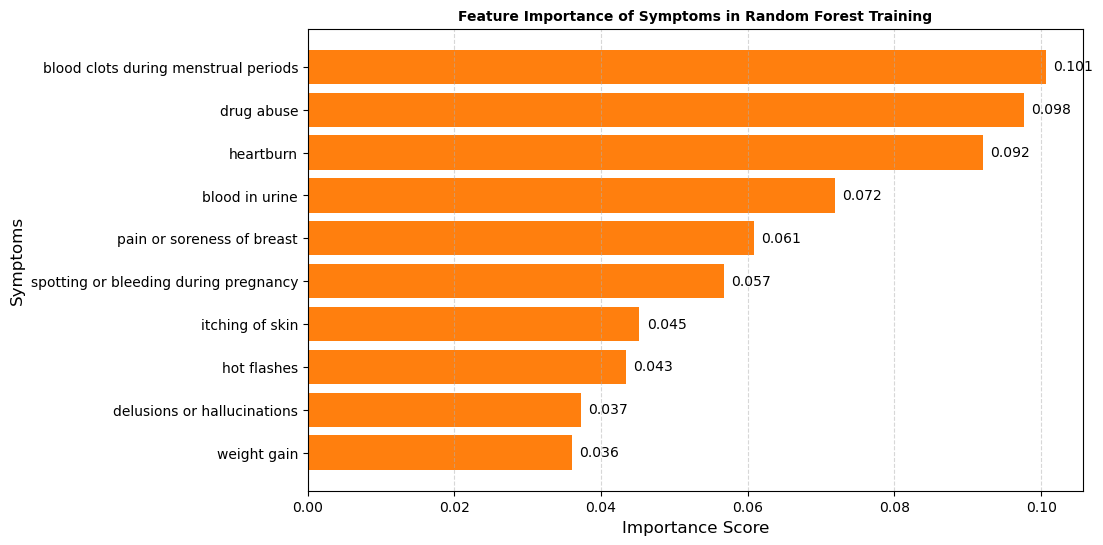

In [39]:
# GRAFIK FEATURE IMPORTANCE
plt.figure(figsize=(10,6))

plt.barh(importance["Feature"][:10], importance["Importance"][:10])

plt.gca().invert_yaxis()

plt.title("Feature Importance of Symptoms in Random Forest Training", fontsize=10, fontweight="bold")

plt.xlabel("Importance Score", fontsize=12)

plt.ylabel("Symptoms", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.5)

bars = plt.barh(importance["Feature"][:10], importance["Importance"][:10])

for bar in bars:
    width = bar.get_width()

    plt.text(width + 0.001, bar.get_y() + bar.get_height()/2, f"{width:.3f}", va="center")

plt.show()

In [40]:
# EVALUASI MODEL
y_pred_encoded = model.predict(X_test)
y_pred = label_encoder.inverse_transform(y_pred_encoded)

acc = accuracy_score(y_test, y_pred)

print(f"Accuracy : {acc:.4f}")

print(classification_report(y_test, y_pred))

Accuracy : 0.9623
                                    precision    recall  f1-score   support

                atrophic vaginitis       0.96      0.97      0.96        66
                     endometriosis       0.95      0.95      0.95        76
idiopathic absence of menstruation       0.99      1.00      0.99        99
  idiopathic nonmenstrual bleeding       1.00      1.00      1.00        19
                     mittelschmerz       1.00      0.90      0.95        10
polycystic ovarian syndrome (pcos)       1.00      0.96      0.98        54
             postpartum depression       1.00      0.99      0.99        99
     premenstrual tension syndrome       1.00      1.00      1.00        27
                  uterine fibroids       0.97      0.97      0.97        90
                      vaginal cyst       0.98      0.99      0.98       243
           vaginal yeast infection       0.86      0.96      0.91       122
                         vaginitis       0.97      0.89      0.93    

In [41]:
# TRAINING & TESTING ACCURACY

y_train_pred_encoded = model.predict(X_train)
y_train_pred = label_encoder.inverse_transform(y_train_pred_encoded)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_pred)

print(f"XGBoost Training Accuracy: {train_acc:.4f}")
print(f"XGBoost Testing Accuracy: {test_acc:.4f}")

XGBoost Training Accuracy: 0.9820
XGBoost Testing Accuracy: 0.9623


In [42]:
# CROSS VALIDATION

y_encoded = label_encoder.fit_transform(y)

cv_scores = cross_val_score(
    model,
    X,
    y_encoded,
    cv=5,
    scoring="accuracy"
)

print("Accuracy tiap fold:")
for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nMean Accuracy : {cv_scores.mean():.4f}")
print(f"Std Accuracy  : {cv_scores.std():.4f}")

Accuracy tiap fold:
Fold 1: 0.9641
Fold 2: 0.9706
Fold 3: 0.9696
Fold 4: 0.9678
Fold 5: 0.9604

Mean Accuracy : 0.9665
Std Accuracy  : 0.0038


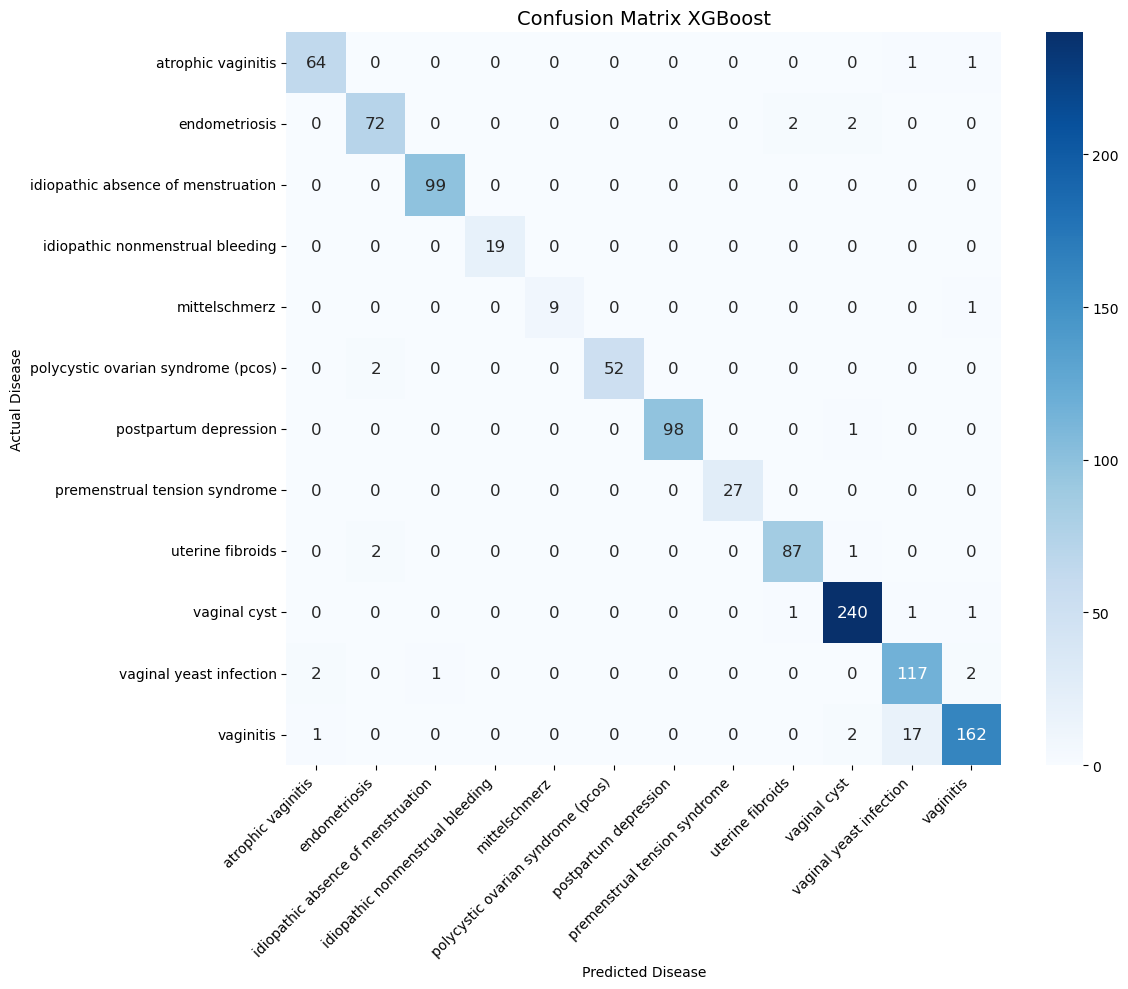

In [43]:
# CONFUSION MATRIX XGBOOST

cm = confusion_matrix(y_test, y_pred)

class_names = label_encoder.classes_

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={"size": 12}
)

plt.title("Confusion Matrix XGBoost", fontsize=14)
plt.xlabel("Predicted Disease")
plt.ylabel("Actual Disease")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [44]:
# MAPPING GEJALA
mapping_gejala = {}

for kolom in X.columns:
    mapping_gejala[kolom.lower()] = kolom
print("Jumlah fitur RF :", len(mapping_gejala))

Jumlah fitur RF : 44


In [45]:
# DAFTAR GEJALA UNTUK INPUT USER

english_gejala = [
    col for col in X.columns
    if col in rekom.columns
]

print("Jumlah gejala:", len(english_gejala))

Jumlah gejala: 44


In [46]:
# INPUT USER
print("="*60)
print("REPRODUCTIVE HEALTH RECOMMENDATION SYSTEM")
print("="*60)

nama = input("Name : ")

umur = int(input("Age : "))

print()

for i, g in enumerate(english_gejala, start=1):
    print(f"{i}. {g}")

pilihan = input("\nEnter symptom number(s) : ")

nomor = [int(x) for x in pilihan.split(",")]

gejala_user = [english_gejala[i-1] for i in nomor]

print()

print("Selected Symptoms :")

for g in gejala_user:
    print("✓", g)

REPRODUCTIVE HEALTH RECOMMENDATION SYSTEM


Name :  buhun
Age :  20



1. anxiety and nervousness
2. depression
3. depressive or psychotic symptoms
4. suprapubic pain
5. drug abuse
6. sharp abdominal pain
7. vomiting
8. headache
9. nausea
10. diarrhea
11. vaginal itching
12. painful urination
13. involuntary urination
14. pain during intercourse
15. frequent urination
16. lower abdominal pain
17. vaginal discharge
18. blood in urine
19. hot flashes
20. intermenstrual bleeding
21. back pain
22. pain during pregnancy
23. pelvic pain
24. burning abdominal pain
25. weight gain
26. heartburn
27. vaginal pain
28. vaginal redness
29. vulvar irritation
30. excessive anger
31. problems during pregnancy
32. spotting or bleeding during pregnancy
33. cramps and spasms
34. delusions or hallucinations
35. pain or soreness of breast
36. blood clots during menstrual periods
37. absence of menstruation
38. long menstrual periods
39. heavy menstrual flow
40. unpredictable menstruation
41. painful menstruation
42. infertility
43. itching of skin
44. premenstrual tension or


Enter symptom number(s) :  44



Selected Symptoms :
✓ premenstrual tension or irritability


In [47]:
# VECTOR USER
user_vector = pd.DataFrame(np.zeros((1, X.shape[1])), columns=X.columns)

for g in gejala_user:
    if g in mapping_gejala:
        kolom = mapping_gejala[g]
        user_vector.loc[0, kolom] = 1

print()

print("Jumlah gejala aktif :")

print(int(user_vector.sum(axis=1)))


Jumlah gejala aktif :
1


In [48]:
# PREDIKSI XGBOOST

prob = model.predict_proba(user_vector)[0]
kelas = label_encoder.classes_

hasil_prediksi = pd.DataFrame({"Penyakit": kelas, "Probabilitas": prob})

hasil_prediksi = hasil_prediksi.sort_values(by="Probabilitas", ascending=False).reset_index(drop=True)

# THRESHOLD XGBOOST
THRESHOLD_PROB = 0.05   # 5%

hasil_lolos = hasil_prediksi[hasil_prediksi["Probabilitas"] >= THRESHOLD_PROB].head(3).copy()

top3 = hasil_lolos.copy()

print("="*60)
print("PREDICTED CONDITIONS")
print("="*60)

if len(hasil_lolos) == 0:
    print("Tidak ada penyakit yang memenuhi")
    print(f"threshold probabilitas {THRESHOLD_PROB*100:.0f}%.")

else:
    for i, row in hasil_lolos.reset_index(drop=True).iterrows():
        print(f"{i+1}. {row['Penyakit']} " f"({row['Probabilitas']*100:.2f}%)")

print("-"*60)
print("NOTES")
print("-"*60)

print(
    "These results are generated by the system,\n"
    "and are not intended to replace a professional medical diagnosis.")

PREDICTED CONDITIONS
1. premenstrual tension syndrome (91.95%)
------------------------------------------------------------
NOTES
------------------------------------------------------------
These results are generated by the system,
and are not intended to replace a professional medical diagnosis.


In [49]:
# SIMILARITY GEJALA
hasil_similarity = []

# Ambil semua fitur TANPA kolom diseases
fitur = X.columns

for _, row in rf.iterrows():

    penyakit = row["diseases"]

    disease_vector = row[fitur].values.astype(int)

    score = jaccard_score(user_vector.iloc[0].astype(int), disease_vector)

    hasil_similarity.append({"Penyakit": penyakit, "Similarity_Gejala": score})

similarity_df = pd.DataFrame(hasil_similarity)

similarity_df = similarity_df.sort_values(by="Similarity_Gejala", ascending=False).reset_index(drop=True)

print("="*60)
print("SIMILARITY GEJALA")
print("="*60)

# RATA-RATA SIMILARITY PER PENYAKIT
similarity_df = similarity_df.groupby("Penyakit", as_index=False).agg({"Similarity_Gejala":"mean"})

display(similarity_df.head(10))

SIMILARITY GEJALA


,Penyakit,Similarity_Gejala
0,atrophic vaginitis,0.000000
1,endometriosis,0.000000
2,idiopathic absence of menstruation,0.000000
3,idiopathic nonmenstrual bleeding,0.000000
4,mittelschmerz,0.000000
5,polycystic ovarian syndrome (pcos),0.000000
6,postpartum depression,0.000000
7,premenstrual tension syndrome,0.110462
8,uterine fibroids,0.000000
9,vaginal cyst,0.000000


In [50]:
display(similarity_df)

hasil = hasil_lolos.merge(similarity_df, on="Penyakit", how="left")

,Penyakit,Similarity_Gejala
0,atrophic vaginitis,0.000000
1,endometriosis,0.000000
2,idiopathic absence of menstruation,0.000000
3,idiopathic nonmenstrual bleeding,0.000000
4,mittelschmerz,0.000000
5,polycystic ovarian syndrome (pcos),0.000000
6,postpartum depression,0.000000
7,premenstrual tension syndrome,0.110462
8,uterine fibroids,0.000000
9,vaginal cyst,0.000000


In [51]:
mapping_penyakit = {

    "atrophic vaginitis": "atrophic vaginitis",

    "endometriosis": "endometriosis",

    "idiopathic absence of menstruation": "idiopathic absence of menstruation",

    "idiopathic nonmenstrual bleeding": "idiopathic nonmenstrual bleeding",

    "mittelschmerz": "mittelschmerz",

    "polycystic ovarian syndrome (pcos)": "polycystic ovarian syndrome (PCOS)",

    "postpartum depression": "postpartum depression",

    "premenstrual tension syndrome": "premenstrual tension syndrome",

    "uterine fibroids": "uterine fibroids",

    "vaginal cyst": "vaginal cyst",

    "vaginal yeast infection": "vaginal yeast infection",

    "vaginitis": "vaginitis"

}

In [52]:
# SIAPKAN SELURUH REKOMENDASI

rekom_filter = pd.DataFrame()

for _, row in hasil.iterrows():

    penyakit = row["Penyakit"]
    probabilitas = row["Probabilitas"]
    similarity_gejala = row["Similarity_Gejala"]

    kolom = mapping_penyakit[penyakit]

    temp = rekom[rekom[kolom] == 1].copy()

    temp["Penyakit"] = penyakit
    temp["Similarity_Gejala"] = similarity_gejala
    temp["Probabilitas"] = probabilitas

    rekom_filter = pd.concat([rekom_filter, temp], ignore_index=True)

In [53]:
mapping_xgb = {
    "suprapubic pain": "suprapubic pain",
    "vaginal itching": "vaginal itching",
    "painful urination": "painful urination",
    "involuntary urination": "involuntary urination",
    "pain during intercourse": "pain during intercourse",
    "frequent urination": "frequent urination",
    "vaginal discharge": "vaginal discharge",
    "blood in urine": "blood in urine",
    "sharp abdominal pain": "sharp abdominal pain",
    "lower abdominal pain": "lower abdominal pain",
    "pain during pregnancy": "pain during pregnancy",
    "pelvic pain": "pelvic pain",
    "vaginal pain": "vaginal pain",
    "vaginal redness": "vaginal redness",
    "anxiety and nervousness": "anxiety and nervousness",
    "depression": "depression",
    "depressive or psychotic symptoms": "depressive or psychotic symptoms",
    "drug abuse": "drug abuse",
    "intermenstrual bleeding": "intermenstrual bleeding",
    "excessive anger": "excessive anger",
    "problems during pregnancy": "problems during pregnancy",
    "delusions or hallucinations": "delusions or hallucinations",
    "cramps and spasms": "cramps and spasms",
    "unpredictable menstruation": "unpredictable menstruation",
    "painful menstruation": "painful menstruation",
    "long menstrual periods": "long menstrual periods",
    "itching of skin": "itching of skin",
    "hot flashes": "hot flashes",
    "spotting or bleeding during pregnancy": "spotting or bleeding during pregnancy",
    "blood clots during menstrual periods": "blood clots during menstrual periods",
    "absence of menstruation": "absence of menstruation",
    "back pain": "back pain",
    "burning abdominal pain": "burning abdominal pain",
    "diarrhea": "diarrhea",
    "headache": "headache",
    "heartburn": "heartburn",
    "heavy menstrual flow": "heavy menstrual flow",
    "infertility": "infertility",
    "nausea": "nausea",
    "pain or soreness of breast": "pain or soreness of breast",
    "premenstrual tension or irritability": "premenstrual tension or irritability",
    "vomiting": "vomiting",
    "vulvar irritation": "vulvar irritation",
    "weight gain": "weight gain"
}

In [54]:
# FITUR CBF
fitur_cbf = []

for g in gejala_user:

    if g in mapping_xgb:

        kolom = mapping_xgb[g]

        if kolom in rekom.columns:
            fitur_cbf.append(kolom)

        else:
            print(
                f"Kolom '{kolom}' tidak ditemukan "
                "di dataset rekomendasi."
            )

print("=" * 60)
print("CBF FEATURES")
print("=" * 60)

print("Gejala user :", gejala_user)
print("Fitur CBF   :", fitur_cbf)
print("Jumlah fitur:", len(fitur_cbf))

CBF FEATURES
Gejala user : ['premenstrual tension or irritability']
Fitur CBF   : ['premenstrual tension or irritability']
Jumlah fitur: 1


In [55]:
# JACCARD SIMILARITY
def jaccard_similarity(a, b):
    intersection = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()

    if union == 0:
        return 0

    return intersection / union

In [56]:
# CONTENT-BASED FILTERING
similarity = []

# USER VECTOR CBF
# ------------------------------------------------------------
# Karena fitur_cbf hanya berisi gejala yang dipilih user,
# setiap fitur pada user vector bernilai 1.

user_cbf = np.ones(len(fitur_cbf), dtype=int)

print("=" * 60)
print("USER CBF VECTOR")
print("=" * 60)

print("Fitur :", fitur_cbf)
print("Vector:", user_cbf)

# HITUNG SIMILARITY USER VS RECOMMENDATION
for _, row in rekom_filter.iterrows():

    item = (row[fitur_cbf].fillna(0).astype(int).values)

    score = jaccard_similarity(user_cbf, item)

    similarity.append(score)

# SIMPAN SIMILARITY
rekom_filter["Similarity"] = similarity

# CBF THRESHOLD
THRESHOLD_CBF = 0.25

rekom_filter = rekom_filter[rekom_filter["Similarity"] > THRESHOLD_CBF].copy()

print("=" * 60)
print("CONTENT-BASED FILTERING")
print("=" * 60)

print("CBF Similarity Threshold :", THRESHOLD_CBF)

print("Jumlah rekomendasi setelah CBF :", len(rekom_filter))

print()
print("REKOMENDASI YANG LOLOS CBF:")

display(
    rekom_filter[[
            "Recommendation_Code",
            "Similarity"]].sort_values(by="Similarity", ascending=False))

USER CBF VECTOR
Fitur : ['premenstrual tension or irritability']
Vector: [1]
CONTENT-BASED FILTERING
CBF Similarity Threshold : 0.25
Jumlah rekomendasi setelah CBF : 4

REKOMENDASI YANG LOLOS CBF:


,Recommendation_Code,Similarity
3,"Limit coffee, tea, and energy drinks",1.0
4,Walk or do light exercise regularly,1.0
6,Manage stress,1.0
8,Drink warm ginger tea,1.0


In [57]:
# GABUNGKAN REKOMENDASI
hasil = []

for nama, grup in rekom_filter.groupby("Recommendation_Code"):
    temp = grup.drop_duplicates(subset="Penyakit")
    hasil.append({

        "Recommendations": nama,

        "Category": grup["Category"].iloc[0],

        "Similarity": grup["Similarity"].max(),

        "Similarity_Gejala": grup["Similarity_Gejala"].max(),

        # Hapus duplikat penyakit
        "Penyakit": temp["Penyakit"].tolist(),

        # Ambil satu probabilitas untuk tiap penyakit
        "Probabilitas": temp["Probabilitas"].tolist()})

hasil = pd.DataFrame(hasil)

In [58]:
# MEAN PROBABILITY

def mean_probability(probabilities):
    return np.mean(probabilities)

hasil["Mean_Probability"] = (hasil["Probabilitas"].apply(mean_probability))

# HYBRID SCORE

hasil["Skor_Relevansi"] = (0.7 * hasil["Similarity"]+ 0.3 * hasil["Mean_Probability"])

print("="*60)
print("HYBRID RECOMMENDATION SCORE")
print("="*60)

display(hasil[[
            "Recommendations",
            "Penyakit",
            "Similarity",
            "Similarity_Gejala",
            "Mean_Probability",
            "Skor_Relevansi"]].sort_values(by="Skor_Relevansi", ascending=False))

HYBRID RECOMMENDATION SCORE


,Recommendations,Penyakit,Similarity,Similarity_Gejala,Mean_Probability,Skor_Relevansi
0,Drink warm ginger tea,[premenstrual tension syndrome],1.0,0.110462,0.919527,0.975858
1,"Limit coffee, tea, and energy drinks",[premenstrual tension syndrome],1.0,0.110462,0.919527,0.975858
2,Manage stress,[premenstrual tension syndrome],1.0,0.110462,0.919527,0.975858
3,Walk or do light exercise regularly,[premenstrual tension syndrome],1.0,0.110462,0.919527,0.975858


In [59]:
# OUTPUT REKOMENDASI

# Urutan awal rekomendasi menggunakan Hybrid Score.
# Semua rekomendasi yang lolos CBF ditampilkan (tanpa Top-N).

hasil_tampil = hasil.sort_values(by="Skor_Relevansi", ascending=False).reset_index(drop=True)

medical = hasil_tampil[hasil_tampil["Category"] == "Medical Recommendation"].copy().reset_index(drop=True)

traditional = hasil_tampil[hasil_tampil["Category"] == "Traditional Recommendation"].copy().reset_index(drop=True)

print("\n" + "=" * 70)
print("SELECTED SYMPTOMS")
print("=" * 70)

for i, symptom in enumerate(gejala_user, start=1):
    print(f"{i}. {symptom}")

print("\n" + "=" * 70)
print("TOP 3 PREDICTED DISEASES")
print("=" * 70)

for i, (_, row) in enumerate(top3.reset_index(drop=True).iterrows(), start=1):
    print(f"{i}. {row['Penyakit']} " f"({row['Probabilitas'] * 100:.2f}%)")

print("\n" + "=" * 70)
print("MEDICAL RECOMMENDATIONS")
print("=" * 70)

if len(medical) == 0:
    print("Tidak ada medical recommendation yang lolos CBF.")
else:
    for i, (_, row) in enumerate(medical.iterrows(), start=1):
        print(f"{i}. {row['Recommendations']}")

print("\n" + "=" * 70)
print("TRADITIONAL RECOMMENDATIONS")
print("=" * 70)

if len(traditional) == 0:
    print("Tidak ada traditional recommendation yang lolos CBF.")
else:
    for i, (_, row) in enumerate(traditional.iterrows(), start=1):
        print(f"{i}. {row['Recommendations']}")


SELECTED SYMPTOMS
1. premenstrual tension or irritability

TOP 3 PREDICTED DISEASES
1. premenstrual tension syndrome (91.95%)

MEDICAL RECOMMENDATIONS
1. Limit coffee, tea, and energy drinks
2. Manage stress
3. Walk or do light exercise regularly

TRADITIONAL RECOMMENDATIONS
1. Drink warm ginger tea


In [60]:
# REINFORCEMENT LEARNING - FEEDBACK DAN Q-TABLE
ALPHA = 0.1
EPSILON = 0.1
Q_TABLE_FILE = "q_table_xgb.pkl"  # DIUBAH PADA NOTEBOOK XGBOOST

# State = konteks 3 penyakit teratas
state = tuple(sorted(top3["Penyakit"].head(3).tolist()))

# Load Q-table dari feedback sebelumnya
if os.path.exists(Q_TABLE_FILE):
    with open(Q_TABLE_FILE, "rb") as f:
        q_table = pickle.load(f)
else:
    q_table = {}

q_table.setdefault(state, {})

# Setiap rekomendasi hasil CBF menjadi action
for action in hasil_tampil["Recommendations"].tolist():
    q_table[state].setdefault(action, 0.0)


# EPSILON-GREEDY
def epsilon_greedy_rank(df, q_values, epsilon=0.1):
    remaining = list(df["Recommendations"])
    ranked = []

    while remaining:
        q_remaining = [q_values.get(action, 0.0) for action in remaining]

        # Exploration
        if random.random() < epsilon:
            action = random.choice(remaining)

        # Exploitation
        else:
            max_q = max(q_remaining)
            candidates = [action for action in remaining if q_values.get(action, 0.0) == max_q]

            # Jika semua Q masih 0, gunakan Hybrid Score
            # agar urutan awal tidak acak.
            if max_q == 0.0:
                action = (df[df["Recommendations"].isin(candidates)].sort_values("Skor_Relevansi", ascending=False).iloc[0]["Recommendations"])
            else:
                action = random.choice(candidates)

        ranked.append(action)
        remaining.remove(action)

    return (df.set_index("Recommendations").loc[ranked].reset_index())


# Tentukan urutan action menggunakan epsilon-greedy.
# HASIL INI HANYA MENENTUKAN URUTAN RATING,
# bukan mengubah daftar rekomendasi yang ditampilkan.
hasil_rating = epsilon_greedy_rank(hasil_tampil.copy(), q_table[state], EPSILON)

print("\n" + "=" * 70)
print("RATING RECOMMENDATIONS")
print("=" * 70)
print("Please rate each recommendation from 1 to 5.")
print("1 = very inappropriate")
print("2 = inappropriate")
print("3 = moderately appropriate")
print("4 = appropriate")
print("5 = very appropriate")

def rating_to_reward(rating):
    return {
        1: -1.0,
        2: -0.5,
        3: 0.0,
        4: 0.5,
        5: 1.0
    }[rating]


# USER FEEDBACK
feedback = []

for _, row in hasil_rating.iterrows():
    action = row["Recommendations"]

    while True:
        try:
            rating = int(input(f"\nRating for '{action}': "))

            if rating in [1, 2, 3, 4, 5]:
                break

            print("Rating must be from 1 to 5.")

        except ValueError:
            print("Please enter a number from 1 to 5.")

    reward = rating_to_reward(rating)

    old_q = q_table[state].get(action, 0.0)

    # One-step Q-learning:
    # Q <- Q + alpha * (reward - Q)
    new_q = old_q + ALPHA * (reward - old_q)

    q_table[state][action] = new_q

    feedback.append({
        "State": state,
        "Recommendation": action,
        "Rating": rating,
        "Reward": reward,
        "Q_Value": new_q
    })


# SIMPAN Q-TABLE
with open(Q_TABLE_FILE, "wb") as f:
    pickle.dump(q_table, f)

print("\n" + "=" * 70)
print("FEEDBACK SAVED")
print("=" * 70)
print(f"Q-table saved successfully to: {Q_TABLE_FILE}")
print(f"Number of feedback entries saved: {len(feedback)}")

# Data feedback pada run ini juga tersedia sebagai DataFrame
feedback_df = pd.DataFrame(feedback)

if len(feedback_df) > 0:
    display(feedback_df)



RATING RECOMMENDATIONS
Please rate each recommendation from 1 to 5.
1 = very inappropriate
2 = inappropriate
3 = moderately appropriate
4 = appropriate
5 = very appropriate



Rating untuk 'Manage stress':  5

Rating untuk 'Walk or do light exercise regularly':  5

Rating untuk 'Limit coffee, tea, and energy drinks':  4

Rating untuk 'Drink warm ginger tea':  4



FEEDBACK SAVED
Q-table saved successfully to: q_table_xgb.pkl
Number of feedback entries saved: 4


,State,Recommendation,Rating,Reward,Q_Value
0,"(premenstrual tension syndrome,)",Manage stress,5,1.0,0.27100
1,"(premenstrual tension syndrome,)",Walk or do light exercise regularly,5,1.0,0.40951
2,"(premenstrual tension syndrome,)","Limit coffee, tea, and energy drinks",4,0.5,0.22100
3,"(premenstrual tension syndrome,)",Drink warm ginger tea,4,0.5,0.22100
